In [2]:
import pandas as pd
import sqlite3
import numpy as np
import os

# Connect using your actual folder name: 'Processed Data'
db_path = '../Processed Data/processed_pharma_sfe.db'

if os.path.exists(db_path):
    conn = sqlite3.connect(db_path)
    print("Database connected successfully!")
else:
    print(f"Error: Database not found at {db_path}")
    print("Please check your folder names in the sidebar.")

# Load the tables
reps = pd.read_sql("SELECT * FROM reps", conn)
sales = pd.read_sql("SELECT * FROM sales", conn)
calls = pd.read_sql("SELECT * FROM calls_cleaned", conn)
prescribers = pd.read_sql("SELECT * FROM prescribers_cleaned", conn)
territories = pd.read_sql("SELECT * FROM territories", conn)

conn.close()
print("All tables loaded successfully!")

Database connected successfully!
All tables loaded successfully!


In [7]:
# 1. Calculate Average Achievement per Rep
rep_ach = sales.groupby('territory_id')['target_achievement_pct'].mean().reset_index()

# 2. Calculate A-tier Reach Rate per Rep
# (How many unique A-tier docs did they visit / total A-tier docs in their territory)
a_docs = prescribers[prescribers['prescriber_tier'] == 'A']['prescriber_id']
rep_reach = calls[calls['prescriber_id'].isin(a_docs)].groupby('rep_id')['prescriber_id'].nunique().reset_index(name='a_tier_reached')
total_a_per_terr = prescribers[prescribers['prescriber_tier'] == 'A'].groupby('territory_id').size().reset_index(name='total_a_targets')

# 3. Merge into Master Feature Set
df_ml = reps.merge(rep_ach, on='territory_id')
df_ml = df_ml.merge(total_a_per_terr, on='territory_id')
df_ml = df_ml.merge(rep_reach, on='rep_id', how='left').fillna(0)
df_ml = df_ml.merge(territories[['territory_id', 'market_potential_index']], on='territory_id')

# Calculate the Reach Rate Feature
df_ml['a_tier_reach_rate'] = (df_ml['a_tier_reached'] / df_ml['total_a_targets']).fillna(0)

# Mock a 'trend' feature (Change in call volume)
df_ml['call_frequency_trend'] = np.random.uniform(-0.15, 0.15, len(df_ml))

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Create Target Variable
df_ml['is_at_risk'] = (df_ml['target_achievement_pct'] < 85).astype(int)

# Select features defined in PDF Section G & I
features = ['a_tier_reach_rate', 'call_frequency_trend', 'tenure_months', 'market_potential_index']
X = df_ml[features]
y = df_ml['is_at_risk']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

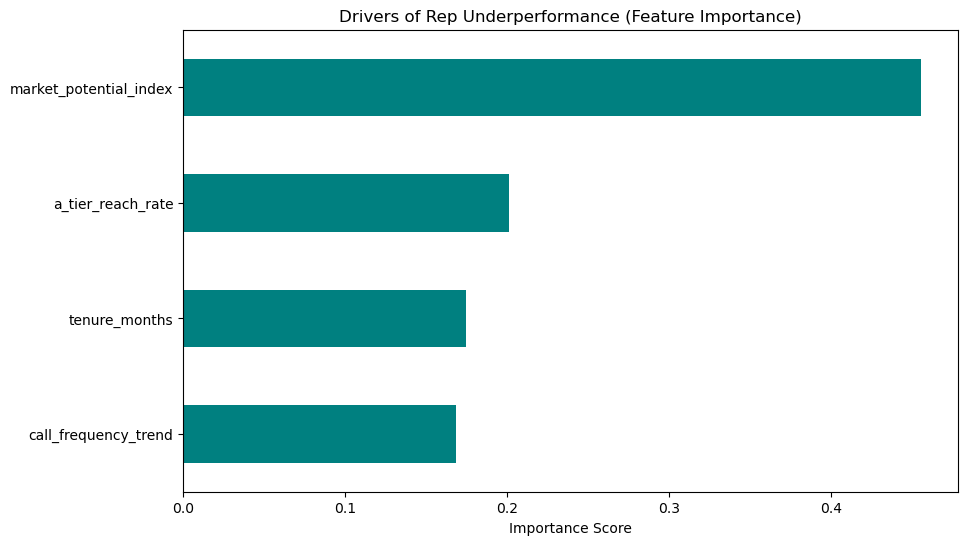

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.Series(model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='teal')
plt.title('Drivers of Rep Underperformance (Feature Importance)')
plt.xlabel('Importance Score')
plt.show()